### PMSM 2D transient convection problem
 
 We aim to solve the same problem than 'steady-state-heat-transfer', but as transient study. Now we can see how long it takes for the system to reach steady-state.

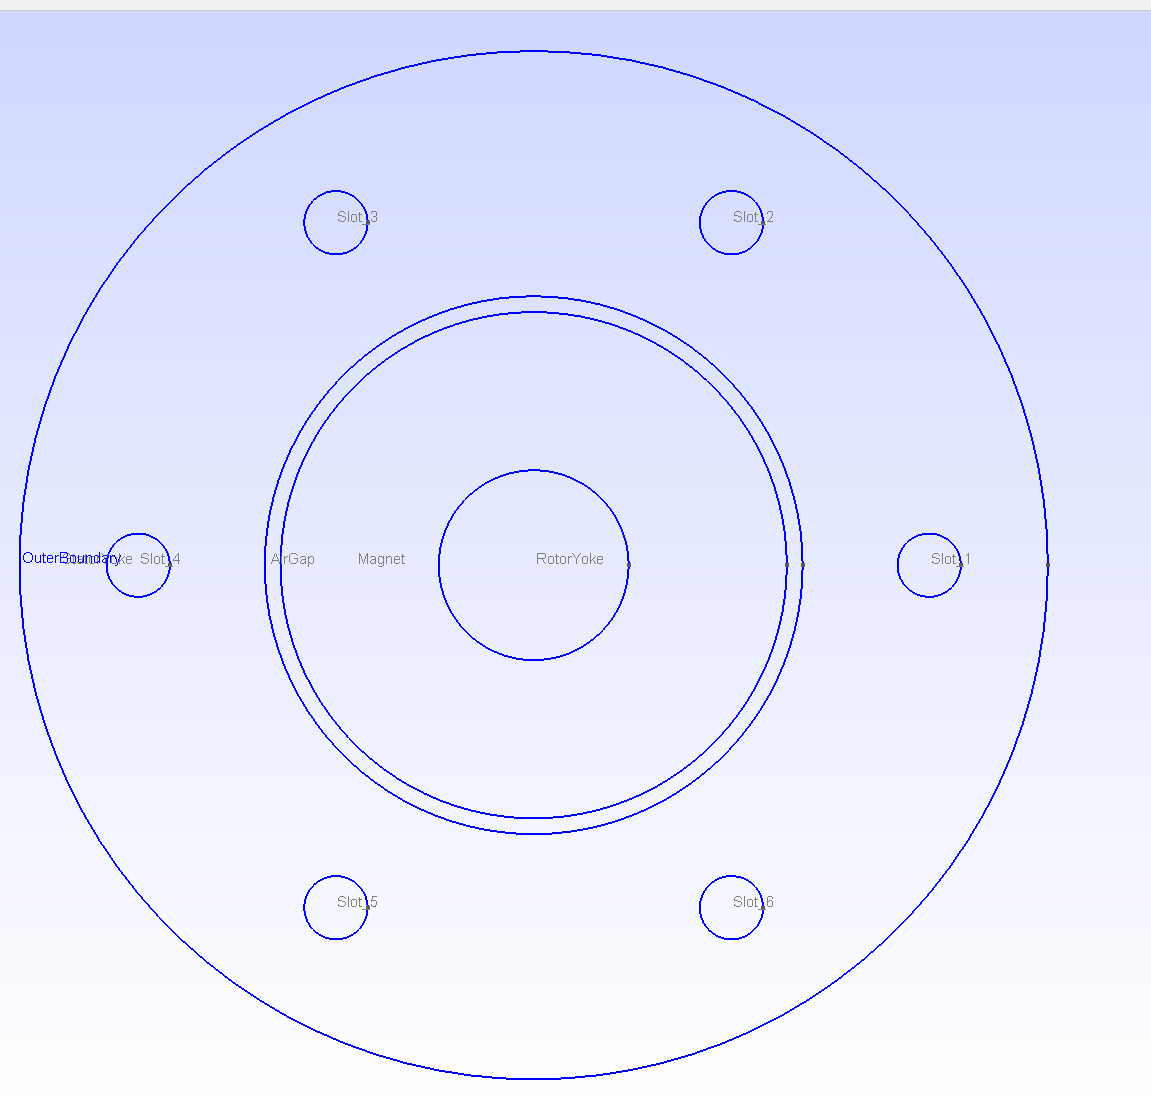

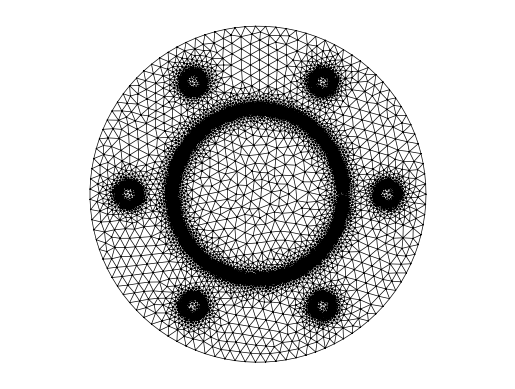

In [ ]:
import meshio
from skfem import *
from skfem.helpers import dot, grad
import numpy as np

from skfem.io.meshio import from_meshio

# Add repository root to Python path. Helps to find files and modules
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent))

m = meshio.read("mesh/mesh_pmsm_2d.msh")

mesh = from_meshio(m)

from skfem.visuals.matplotlib import draw
import matplotlib.pyplot as plt

draw(mesh)
plt.axis("equal")
plt.show()


In [8]:
from skfem import Basis, ElementTriP2

# Second order tringular elements.
e = ElementTriP2()
basis = Basis(mesh, e, intorder=4)

basis_rotor_yoke = basis.with_elements(mesh.subdomains["RotorYoke"])
basis_stator_yoke = basis.with_elements(mesh.subdomains["StatorYoke"])
basis_air_gap = basis.with_elements(mesh.subdomains["AirGap"])
basis_magnet = basis.with_elements(mesh.subdomains["Magnet"])


from skfem import FacetBasis

basis_robin_bnd = FacetBasis(
    mesh,
    basis.elem,
    facets=mesh.boundaries["OuterBoundary"]
)

slot_bases = [
    basis.with_elements(mesh.subdomains[f"Slot_{i}"])
    for i in range(1, 7)
]

from skfem import Functional
@Functional
def area(w):
    return 1.0

print()
slot_area = area.assemble(slot_bases[0])
print("In units of m: ", slot_area)


In units of m:  5.007820143519473e-05


# Formulation

We are trying to solve temperature distribution in the pmsm motor T(x,y) in steady state conditions. We have slots as heat sources, and outer boundary has convection boundary condition.

### Steady-state heat conduction

The steady-state heat equation is

$$
-\nabla \cdot \left(k \nabla T\right) = Q
\qquad \text{in } \Omega,
$$

where

- $T$ is the temperature [K],
- $k$ is the thermal conductivity [W/(m K)],
- $Q$ is the volumetric heat generation [W/m$^3$],
- $\Omega$ is the computational domain.


# Boundary conditions

### Robin boundary condition / Convection BC

Convection to an ambient environment is described by

$$
-k\nabla T \cdot \mathbf n
=
h(T-T_\infty)
\qquad \text{on } \Gamma_R,
$$

where

- $h$ is the convection coefficient [W/(m$^2$ K)],
- $T_\infty$ is the ambient temperature [K].

We add this into weak form of heat equations, which turns out to be after multiplying test function and integration py parts:

$$
\boxed{
\int_\Omega
k\nabla v\cdot\nabla T\,d\Omega
=
\int_\Omega vQ\,d\Omega
+
\int_\Gamma
v\,k\nabla T\cdot\mathbf n\,d\Gamma
}
$$


### Robin boundary

The Robin boundary condition is

$$
-k\nabla T\cdot\mathbf n
=
h(T-T_\infty).
$$

Rearranging,

$$
k\nabla T\cdot\mathbf n
=
-h(T-T_\infty).
$$

Expanding,

$$
k\nabla T\cdot\mathbf n
=
-hT+hT_\infty.
$$

Substituting into the weak form gives

$$
\int_{\Gamma_R}
v\,k\nabla T\cdot\mathbf n\,d\Gamma
=
\int_{\Gamma_R}
v(-hT+hT_\infty)\,d\Gamma.
$$

Therefore,

$$
\boxed{
\int_\Omega
k\nabla v\cdot\nabla T\,d\Omega
+
\int_{\Gamma_R}
hvT\,d\Gamma
=
\int_\Omega vQ\,d\Omega
+
\int_{\Gamma_R}
hvT_\infty\,d\Gamma
}
$$

We notice:
- First term traditional conductivity matrix / stiffness matrix
- Second term, coupling convection from boundary to the domain nodes. Looks like mass matrix, but only in boundary nodes
- Third term, source term where the heat is generated
- Fourth term: Neumann term, defines heat flux on boundary. T_inf is known.


In [ ]:
### Material parameters:
k_air = 0.026 # W/(m*K)       / Air
k_pm = 8 # W/(m*K)            / NdFeB
k_rotor_yoke = 30 # W/(m*K)   / Electrical steel
k_stator_yoke = 30 # W/(m*K)  / Electrical steel
k_slot = 380 # W/(m*K)        / Copper

sigma_slot = 5.8e7  # S/m     / Copper

### Heat sources:

# Copper losses Q = J^2/sigma
I_0 = 2
Nturns = 100
J_rms = I_0 * Nturns / (np.sqrt(2) * slot_area) # A/m^2

Q_slot = J_rms**2 / sigma_slot # W/m^3 
print("Copper losses in slots [W/m^3]: ", Q_slot)
Q_pm = 0.0 # W/m^3
Q_air = 0.0 # W/m^3
Q_iron = 0.0  # W/m^3

# Convection params for ambient air
h_air = 10.0          # W/(m^2 K)  
T_inf = 20.0+273.15     # K


### ASSEMBLE SYSTEM


# First term: conductivity matrix
@BilinearForm
def conduction_bilinear(T, v, w):
    return w.k*dot(grad(T), grad(v))

K = conduction_bilinear.assemble(basis_rotor_yoke, k=k_rotor_yoke)
K += conduction_bilinear.assemble(basis_stator_yoke, k=k_stator_yoke)
K += conduction_bilinear.assemble(basis_air_gap, k=k_air)
K += conduction_bilinear.assemble(basis_magnet, k=k_pm)

for basis_i in slot_bases:
    K += conduction_bilinear.assemble(basis_i, k=k_slot)

# Second term: Robin boundary condition matrix,  coupling domain temperature to ambient temperature
@BilinearForm
def robin_bilinear(T, v, w):
    return w.h*T*v

K += robin_bilinear.assemble(basis_robin_bnd, h=h_air)

# Third term: heat source vector
@LinearForm
def source_linear(v, w):
    return w.Q * v

f = source_linear.assemble(basis_rotor_yoke, Q=Q_iron)
f += source_linear.assemble(basis_stator_yoke, Q=Q_iron)
f += source_linear.assemble(basis_air_gap, Q=Q_air)
f += source_linear.assemble(basis_magnet, Q=Q_pm)
# Copper losses in slots
for basis_i in slot_bases:
    f += source_linear.assemble(basis_i, Q=Q_slot)

# Fourth term: Neumann boundary condition vector, how much heat is leaving system to ambient air.
@LinearForm
def robin_linear(v, w):
    return w.q_n * v

# We define normal vector as outward pointing ,  so q_n = +h*T_inf means heat is leaving the motor to domain
f += robin_linear.assemble(
    basis_robin_bnd,
    q_n=h_air*T_inf
)

T_sol = solve(K, f)


Copper losses in slots [W/m^3]:  137500.58839666407


Visualize

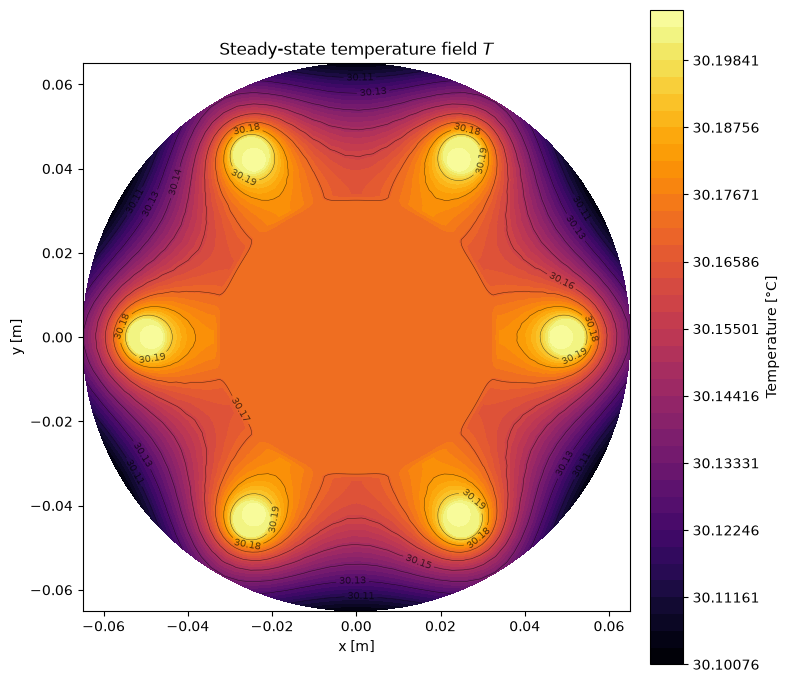

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

# --------------------------------------------------------------
# Assumes:
#   basis.mesh.p  -> (2, n_nodes) array of node coordinates
#   basis.mesh.t  -> (3, n_elements) array of triangle connectivity
#   T_sol         -> nodal temperature solution, shape (n_nodes,)
# --------------------------------------------------------------

x = basis.doflocs[0]
y = basis.doflocs[1]
tris = basis.mesh.t.T  # matplotlib wants (n_elements, 3)

triang = mtri.Triangulation(x, y, tris)

# Convert to Celsius for readability (optional -- comment out to keep Kelvin)
T_plot = T_sol - 273.15
label_unit = "°C"

# Use actual data range instead of a hardcoded +-1K window around T_inf
T_min, T_max = T_plot.min(), T_plot.max()
pad = 0.02 * (T_max - T_min if T_max > T_min else 1.0)

fig, ax = plt.subplots(figsize=(8, 8))

# Filled contour -- smooth, physically continuous field
n_levels = 40
levels = np.linspace(T_min - pad, T_max + pad, n_levels)

cf = ax.tricontourf(triang, T_plot, levels=levels, cmap="inferno")

# Thin black contour lines on top, labeled at a coarser interval
coarse_levels = np.linspace(T_min, T_max, 10)
cl = ax.tricontour(triang, T_plot, levels=coarse_levels,
                    colors="black", linewidths=0.4, alpha=0.6)
ax.clabel(cl, inline=True, fontsize=7, fmt="%.2f")

# Optional: draw mesh edges very faintly to show discretization
# ax.triplot(triang, color="k", lw=0.05, alpha=0.15)

ax.set_aspect("equal")
ax.set_title(r"Steady-state temperature field $T$")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")

cbar = fig.colorbar(cf, ax=ax, shrink=0.85, pad=0.03)
cbar.set_label(f"Temperature [{label_unit}]")

plt.tight_layout()
plt.show()

Verify

In [6]:
import numpy as np

# Load COMSOL data
data = np.loadtxt(
    "verification/T_field.txt",
    comments="%"
)

points = data[:, :2]
T_comsol = data[:, 2]


from utils.field_interpolation import eval_scalar_field_at_points
from utils.field_verification import compare_point_values
# Evaluate your FE solution at the exact same points
T_python = eval_scalar_field_at_points(
    T_sol,
    basis,
    points,
);

compare_point_values(
    T_python,
    T_comsol,
    points,
    quantity_name="T",
    plot = False
);

[T] N points           : 81
[T] Absolute L2 (RMS)  : 3.372055e-02
[T] Reference RMS norm : 3.033545e+02
[T] Relative L2 error  : 0.0111%

     x [m]      y [m]          T_own          T_ref      abs err  rel err %
-2.0000e-02 4.0000e-02   3.033437e+02   3.033776e+02  -3.3915e-02     0.0112
-3.0000e-02 4.0000e-02   3.033381e+02   3.033720e+02  -3.3872e-02     0.0112
-2.0000e-02 3.0000e-02   3.033296e+02   3.033634e+02  -3.3830e-02     0.0112
2.0000e-02 4.0000e-02   3.033437e+02   3.033775e+02  -3.3825e-02     0.0111
-1.0000e-02 4.0000e-02   3.033198e+02   3.033536e+02  -3.3818e-02     0.0111
3.0000e-02 4.0000e-02   3.033382e+02   3.033720e+02  -3.3808e-02     0.0111
-3.0000e-02 3.0000e-02   3.033203e+02   3.033541e+02  -3.3802e-02     0.0111
-2.0000e-02 -4.0000e-02   3.033437e+02   3.033775e+02  -3.3795e-02     0.0111
0.0000e+00 4.0000e-02   3.033127e+02   3.033465e+02  -3.3783e-02     0.0111
-4.0000e-02 0.0000e+00   3.033343e+02   3.033681e+02  -3.3782e-02     0.0111
-3.0000e-02 2.0000

In [7]:
import numpy as np

# Load COMSOL data
data = np.loadtxt(
    "verification/T_field_bnd.txt",
    comments="%"
)

points = data[:, :2]
T_comsol = data[:, 2]


from utils.field_interpolation import eval_scalar_field_at_points
from utils.field_verification import compare_point_values
# Evaluate your FE solution at the exact same points
T_python = eval_scalar_field_at_points(
    T_sol,
    basis,
    points,
);

compare_point_values(
    T_python,
    T_comsol,
    points,
    quantity_name="T",
    plot = False
);

[T] N points           : 73
[T] Absolute L2 (RMS)  : 3.356190e-02
[T] Reference RMS norm : 3.033116e+02
[T] Relative L2 error  : 0.0111%

     x [m]      y [m]          T_own          T_ref      abs err  rel err %
-2.7048e-02 5.4378e-02   3.033009e+02   3.033347e+02  -3.3754e-02     0.0111
-3.2000e-02 5.1962e-02   3.033014e+02   3.033351e+02  -3.3749e-02     0.0111
-2.1889e-02 5.6382e-02   3.032930e+02   3.033267e+02  -3.3732e-02     0.0111
-3.6709e-02 4.9149e-02   3.032934e+02   3.033272e+02  -3.3718e-02     0.0111
-1.6564e-02 5.7956e-02   3.032833e+02   3.033170e+02  -3.3702e-02     0.0111
-4.1138e-02 4.5963e-02   3.032826e+02   3.033163e+02  -3.3680e-02     0.0111
2.7048e-02 5.4378e-02   3.033009e+02   3.033346e+02  -3.3680e-02     0.0111
-1.1113e-02 5.9088e-02   3.032755e+02   3.033092e+02  -3.3675e-02     0.0111
3.2000e-02 5.1962e-02   3.033014e+02   3.033350e+02  -3.3673e-02     0.0111
2.1889e-02 5.6382e-02   3.032930e+02   3.033266e+02  -3.3668e-02     0.0111
-5.5780e-03 5.9772e

Good agreement with comsol